<html>
<h1 style="text-align: center;">Dataset Description</h1>

<h2 style="text-align: center;">Dataset Source: Kaggle – Titanic: Machine Learning from Disaster</h2>

<h3>The Titanic dataset contains information about passengers such as:</h3>
<ul>
   <li>Passenger class (Pclass)</li>
    
   <li>Name</li>

   <li>Sex</li>

   <li>Age</li>

   <li>SibSp (No. of siblings / spouses aboard the Titanic)</li>
   <li> Parch (No. of parents / children aboard the Titanic)</li>
   <li> Embarked(Port of Embarkation:C = Cherbourg, Q = Queenstown, S = Southampton)</li>
   <li> Fare </li>
   <li> Survival status (0 = Not Survived, 1 = Survived)</li>
</ul>
</html>

## 1.Importing labraies and Dataset

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
import kagglehub
path = kagglehub.dataset_download("yasserh/titanic-dataset")

Using Colab cache for faster access to the 'titanic-dataset' dataset.


In [8]:
import os
print(os.listdir(path))

['Titanic-Dataset.csv']


In [9]:
csv_file_path = os.path.join(path, 'Titanic-Dataset.csv')
df = pd.read_csv(csv_file_path)
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2.Data Cleaning

### Checking datatypes

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Checking missing values

In [11]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handing missing Embarked values
#### -> Embarked values have only 2 missing values
#### -> We can simply fill it with Mode value

In [12]:
df["Embarked"].fillna(df.Embarked.mode()[0],inplace=True)

### Handling Missing Age Values

#### -> Age has missing values

#### -> We replace missing ages with the median age

In [13]:
df['Age'].fillna(df['Age'].median(), inplace=True)

### Drop Columns with Too Many Missing Values

#### -> Cabin has 77% of missing values → removed

In [14]:
df.drop(columns=['Cabin'], inplace=True)

### Verify Cleaning

In [15]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 3.Exploratory Data Analysis (EDA)

### Q1: Who survived more — Males or Females?

In [16]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


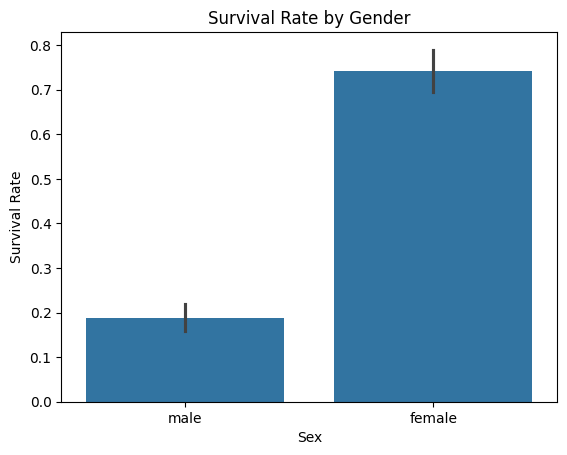

In [17]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

#### Insight:

#### -> Females had a much higher survival rate than males.

#### -> This aligns with the “women first” evacuation policy.

### Q2: Did Passenger Class Affect Survival Chances?

In [18]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


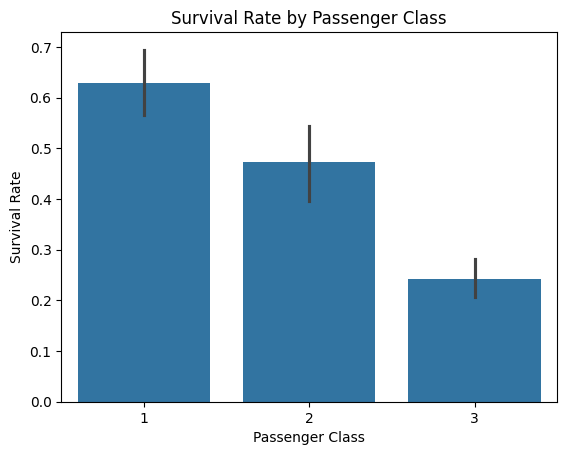

In [19]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

#### Insight:

#### -> 1st class passengers had the highest survival rate

#### -> 3rd class passengers had the lowest survival rate

#### -> Higher socio-economic status improved survival chances

### Q3: What Was the Survival Rate by Age Group?

In [20]:
bins = [0, 12, 18, 35, 60, 80]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [21]:
df.groupby('AgeGroup')['Survived'].mean()

,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
Young Adult,0.353271
Adult,0.400000
Senior,0.227273


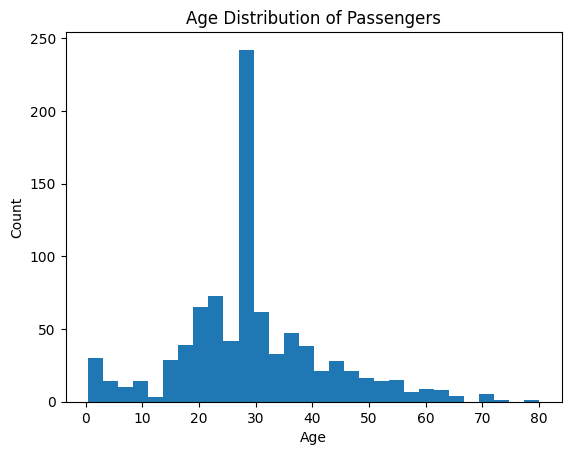

In [22]:
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### Insight:

#### -> Children had a better survival rate

#### -> Very old passengers had lower survival chances

#### -> Most passengers were young adults

## 4. Analysis Conclusion
#### -> Gender mattered: Females survived more than males

#### -> Passenger class mattered: Higher class → higher survival

#### -> Age mattered: Children had better survival chances

#### -> Visualization helped clearly understand survival patterns

##

## 5. Machine Learning


### Feature Selection

#### For building a machine learning model, some features are not needed or require transformation so we can drop those columes:

In [23]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'AgeGroup'], inplace=True)

In [24]:
df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S


#### Feature Transformation or Encoding

In [25]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [26]:
ohe = OneHotEncoder(sparse_output=False,drop="first")
le = LabelEncoder()

In [27]:
ohe_col = ohe.fit_transform(df[['Sex']])
df["sex_encoded(male)"] = pd.DataFrame(ohe_col)
le_col = le.fit_transform(df['Embarked'])
df["embarked_encoded"] = pd.DataFrame(le_col)
df.drop(columns=['Sex','Embarked'],inplace=True)
display(df.head())


,Survived,Pclass,Age,SibSp,Parch,Fare,sex_encoded(male),embarked_encoded
0,0,3,22.0,1,0,7.2500,1.0,2
1,1,1,38.0,1,0,71.2833,0.0,0
2,1,3,26.0,0,0,7.9250,0.0,2
3,1,1,35.0,1,0,53.1000,0.0,2
4,0,3,35.0,0,0,8.0500,1.0,2


##

<Axes: >

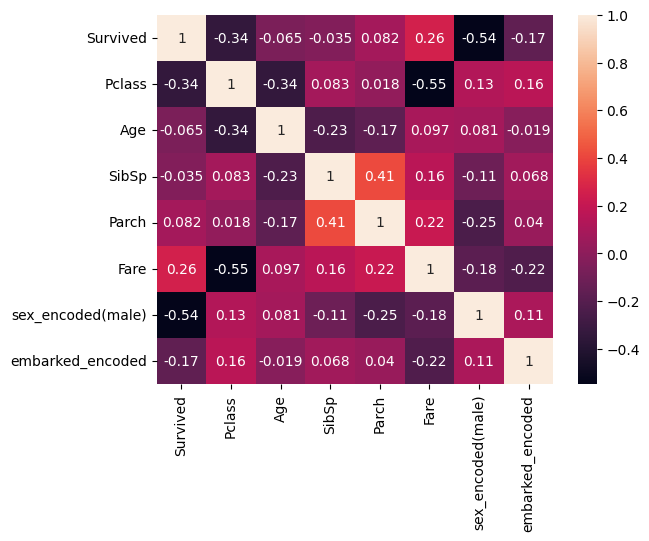

In [32]:
sns.heatmap(df.corr(),annot=True)

#### Train-Test Split

In [28]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.25, random_state=42)

#### Model fitting

In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [31]:
lr.score(x_test,y_test)

0.8071748878923767

#### Model Evaluation: Classification Report and Confusion Matrix

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       134
           1       0.77      0.73      0.75        89

    accuracy                           0.81       223
   macro avg       0.80      0.79      0.80       223
weighted avg       0.81      0.81      0.81       223



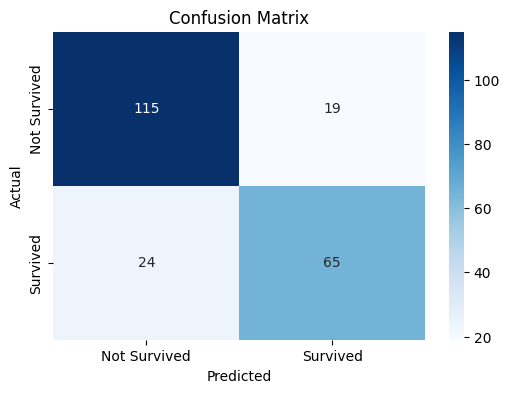

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the test set
y_pred = lr.predict(x_test)

# Generate and print the classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Explanation of Model Errors:

*   **Classification Report**: This report provides precision, recall, and F1-score for each class (0 = Not Survived, 1 = Survived).
    *   **Precision**: Of all instances predicted as positive (or negative), how many were actually positive (or negative)?
    *   **Recall**: Of all actual positive (or negative) instances, how many were correctly predicted?
    *   **F1-Score**: The harmonic mean of precision and recall, providing a balanced measure.

*   **Confusion Matrix**: This visualizes the performance of a classification model.
    *   **True Negatives (TN)** (Top-left): Correctly predicted 'Not Survived'.
    *   **False Positives (FP)** (Top-right): Predicted 'Survived' but actually 'Not Survived' (Type I error).
    *   **False Negatives (FN)** (Bottom-left): Predicted 'Not Survived' but actually 'Survived' (Type II error).
    *   **True Positives (TP)** (Bottom-right): Correctly predicted 'Survived'.

By examining these metrics and the confusion matrix, you can identify if your model is having trouble with specific classes (e.g., misclassifying more survivors than non-survivors, or vice-versa) and understand the types of errors it's making.